In [5]:
pip install matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: C:\Users\HP\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [6]:
pip install seaborn

     ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
     ------------ -------------------------- 92.2/294.9 kB 5.5 MB/s eta 0:00:01
     ------------------------------------ - 286.7/294.9 kB 4.5 MB/s eta 0:00:01
     -------------------------------------- 294.9/294.9 kB 3.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: C:\Users\HP\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [8]:
data_path = Path(r"C:\Users\HP\OneDrive\Desktop\Retail_Capstone_Project\data\clean_dataset.csv")

df = pd.read_csv(data_path)

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully
Rows: 10
Columns: 15


,order_id,order_date,customer_segment,city,category,quantity,unit_price,discount_pct,payment_status,year,month,month_name,gross_sales,discount_amount,net_sales
0,RT-1001,2026-01-03,Student,Chennai,Learning Kit,2.0,799,10.0,Paid,2026,1,January,1598.0,159.80,1438.20
1,RT-1002,2026-01-09,Fresher,Bengaluru,Course Access,1.0,1499,0.0,Paid,2026,1,January,1499.0,0.00,1499.00
2,RT-1003,2026-01-05,Student,Chennai,Course Access,1.0,1499,0.0,Pending,2026,1,January,1499.0,0.00,1499.00
3,RT-1004,2026-01-07,Professional,Hyderabad,Learning Kit,3.0,799,5.0,Paid,2026,1,January,2397.0,119.85,2277.15
4,RT-1005,2026-01-09,Fresher,Unknown,Mentor Session,1.0,999,0.0,Failed,2026,1,January,999.0,0.00,999.00


In [9]:
print(df.columns.tolist())
print(df.shape)

['order_id', 'order_date', 'customer_segment', 'city', 'category', 'quantity', 'unit_price', 'discount_pct', 'payment_status', 'year', 'month', 'month_name', 'gross_sales', 'discount_amount', 'net_sales']
(10, 15)


In [10]:
total_revenue = df["net_sales"].sum()

total_orders = df["order_id"].nunique()

total_quantity = df["quantity"].sum()

average_order_value = total_revenue / total_orders

average_discount = df["discount_pct"].mean()

print("EXECUTIVE KPI SUMMARY")
print("-" * 40)
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Quantity: {total_quantity:,}")
print(f"Average Order Value: ₹{average_order_value:,.2f}")
print(f"Average Discount: {average_discount:.2f}%")

EXECUTIVE KPI SUMMARY
----------------------------------------
Total Revenue: ₹13,557.65
Total Orders: 10
Total Quantity: 15.0
Average Order Value: ₹1,355.77
Average Discount: 13.00%


# Create the Executive Summary

The executive report needs a high-level summary.

We will answer:

# Question 1

How much revenue did the business generate?

# Question 2

What categories generated the most revenue?

# Question 3

Which customer segments generated the most revenue?

# Question 4

Which cities generated the most revenue?

# Question 5

What risks or weaknesses are visible?

# Question 6

What three actions should management consider?

In [11]:
# Analyze key revenue drivers

category_revenue = (
    df.groupby("category")["net_sales"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

category
Course Access     7045.30
Learning Kit      4514.35
Mentor Session    1998.00
Name: net_sales, dtype: float64

In [12]:
# Calculate Percentage

category_share = (
    category_revenue / category_revenue.sum() * 100
).round(2)

category_analysis = pd.DataFrame({
    "Revenue": category_revenue,
    "Revenue_Share_%": category_share
})

category_analysis

,Revenue,Revenue_Share_%
category,,
Course Access,7045.30,51.97
Learning Kit,4514.35,33.30
Mentor Session,1998.00,14.74


In [13]:
# Analyze customer segments

segment_revenue = (
    df.groupby("customer_segment")["net_sales"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue

customer_segment
Professional    4825.45
Student         4735.20
Fresher         3997.00
Name: net_sales, dtype: float64

In [14]:
# Calculate Percentage

segment_share = (
    segment_revenue / segment_revenue.sum() * 100
).round(2)

segment_analysis = pd.DataFrame({
    "Revenue": segment_revenue,
    "Revenue_Share_%": segment_share
})

segment_analysis

,Revenue,Revenue_Share_%
customer_segment,,
Professional,4825.45,35.59
Student,4735.20,34.93
Fresher,3997.00,29.48


In [15]:
# Analyze geographic revenue

city_revenue = (
    df.groupby("city")["net_sales"]
    .sum()
    .sort_values(ascending=False)
)

city_revenue.head(15)

city
Chennai      3736.20
Bengaluru    2998.00
Delhi        2548.30
Hyderabad    2277.15
Kochi         999.00
Unknown       999.00
Mumbai          0.00
Name: net_sales, dtype: float64

In [16]:
top_cities = city_revenue.head(15)

top_cities

city
Chennai      3736.20
Bengaluru    2998.00
Delhi        2548.30
Hyderabad    2277.15
Kochi         999.00
Unknown       999.00
Mumbai          0.00
Name: net_sales, dtype: float64

In [17]:
# Analyze monthly revenue

monthly_revenue = (
    df.groupby(["year", "month"])["net_sales"]
    .sum()
    .reset_index()
    .sort_values(["year", "month"])
)

monthly_revenue

,year,month,net_sales
0,2026,1,13557.65


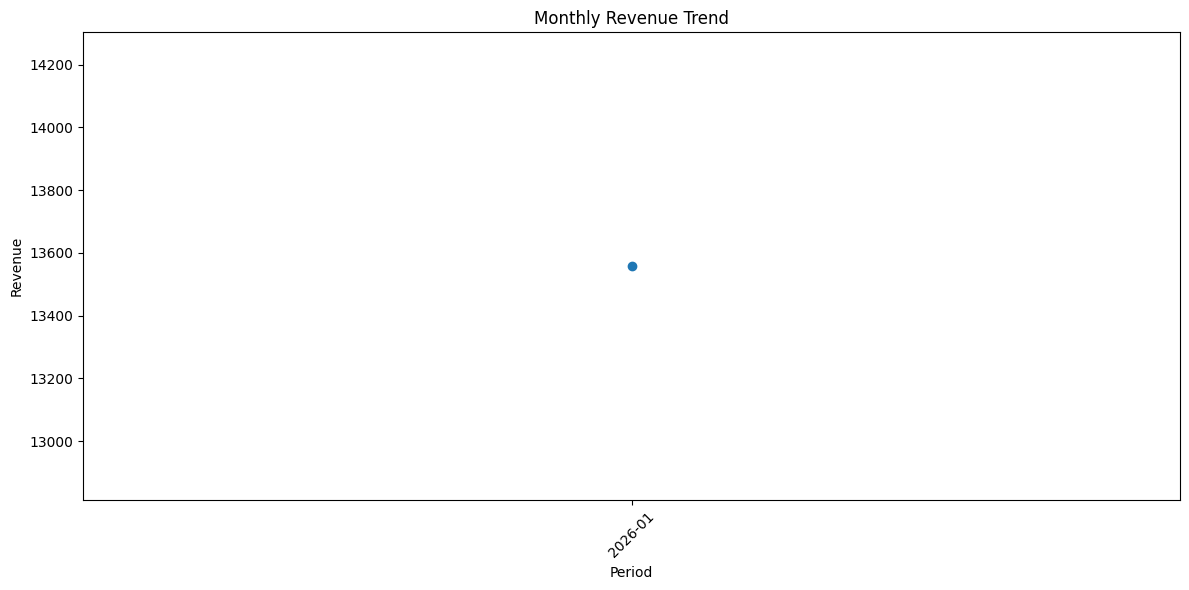

In [18]:
# Create chart

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue["net_sales"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Period")
plt.ylabel("Revenue")

plt.xticks(
    range(len(monthly_revenue)),
    monthly_revenue.apply(
        lambda x: f"{int(x['year'])}-{int(x['month']):02d}",
        axis=1
    ),
    rotation=45
)

plt.tight_layout()
plt.show()

In [19]:
# Analyze payment status

payment_analysis = (
    df.groupby("payment_status")["net_sales"]
    .agg(["sum", "count"])
    .sort_values("sum", ascending=False)
)

payment_analysis

,sum,count
payment_status,,
Paid,7012.35,6
Pending,2998.00,2
Refunded,2548.30,1
Failed,999.00,1


In [20]:
# Analyze discounts

discount_analysis = (
    df.groupby("discount_pct")["net_sales"]
    .agg(["sum", "count"])
    .sort_values("sum", ascending=False)
)

discount_analysis.head(10)

,sum,count
discount_pct,,
0.0,7294.00,6
15.0,2548.30,1
5.0,2277.15,1
10.0,1438.20,1
100.0,0.00,1


In [21]:
print("Average discount:", df["discount_pct"].mean())
print("Maximum discount:", df["discount_pct"].max())

Average discount: 13.0
Maximum discount: 100.0


# Identify risk areas

We need a dedicated Risk Analysis section.

Potential risks that can be investigated from your dataset include:

Risk 1 — Revenue concentration

If a small number of categories/cities generate a large percentage of revenue, the business may have concentration exposure.

Risk 2 — Payment status

Analyze whether unsuccessful/pending payment records represent a meaningful share of transactions or revenue.

Risk 3 — Discount dependency

Analyze whether substantial revenue is associated with high discount levels.

Risk 4 — Geographic concentration

Analyze whether revenue is heavily concentrated in a small number of cities.

Risk 5 — Revenue volatility

Use the monthly trend to identify unusually high or low periods.

Important: We will only call something a risk when the analysis provides evidence for it.

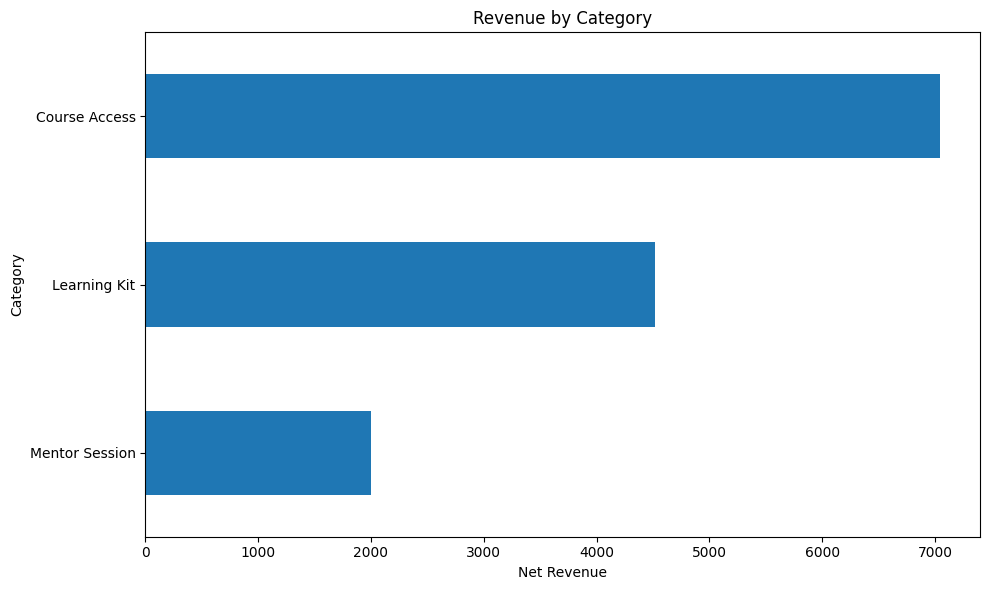

In [22]:
# Create a Revenue Driver chart

plt.figure(figsize=(10, 6))

category_revenue.sort_values().plot(kind="barh")

plt.title("Revenue by Category")
plt.xlabel("Net Revenue")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

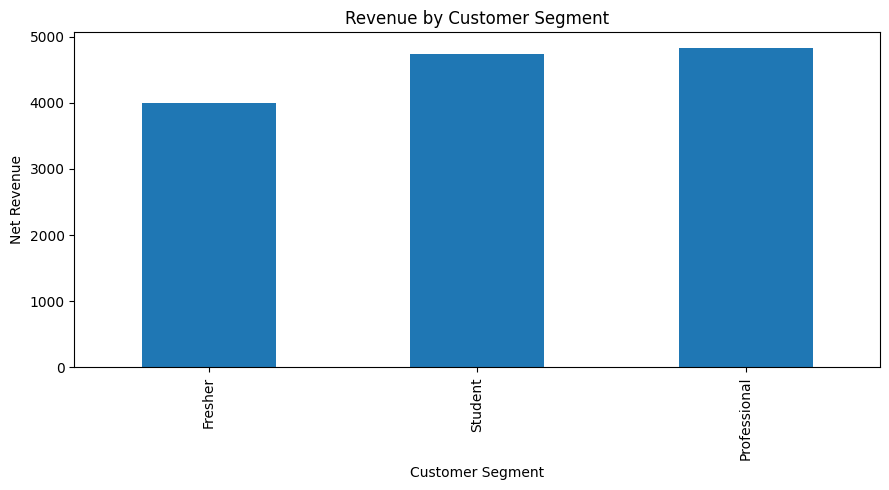

In [23]:
# Create Customer Segment chart

plt.figure(figsize=(9, 5))

segment_revenue.sort_values().plot(kind="bar")

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Net Revenue")

plt.tight_layout()
plt.show()

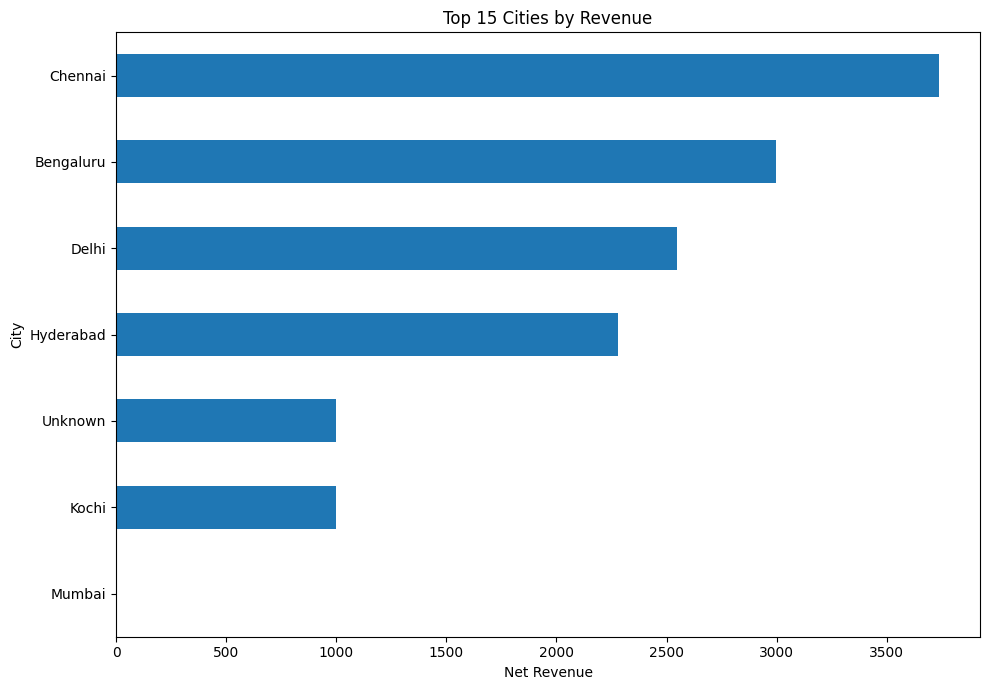

In [24]:
# Create Geographic Revenue chart

plt.figure(figsize=(10, 7))

top_cities.sort_values().plot(kind="barh")

plt.title("Top 15 Cities by Revenue")
plt.xlabel("Net Revenue")
plt.ylabel("City")

plt.tight_layout()
plt.show()

# Create the three strategic recommendations

This is one of the most important parts of this  assignment.

* We need exactly 3 strategic recommendations.

Do not simply write generic recommendations like:

--->"Increase sales."

Each recommendation should have this structure:

                        Finding
                           ↓
                Business implication
                           ↓
                    Recommended action
                           ↓
                     Expected impact
                           ↓
                Implementation timeline

For example, the analysis might reveal:

--> Finding:
One category contributes a large share of revenue.

-->Implication:
Revenue is concentrated in that category.

-->Recommendation:
Protect and expand the high-performing category while
developing secondary categories.

-->Impact:
Revenue diversification and reduced concentration exposure.

-->Timeline:
0–3 months

We will determine your actual three recommendations from your dataset rather than inventing them.

# Calculate ROI projections

The assignment specifically requires:

Include ROI projections.

Because your dataset does not necessarily contain actual implementation costs, we should clearly label assumptions rather than presenting invented financial results as facts.

**Create an assumption table like:**

Recommendation | Estimated Investment | Expected Revenue Impact | ROI

**The formula is:ROI % =(Expected Benefit - Investment)/Investment× 100**

For example, in Python:

investment = 100000
expected_benefit = 150000

roi = ((expected_benefit - investment) / investment) * 100

print(f"Projected ROI: {roi:.2f}%")
Important

These numbers are scenario assumptions, not historical results.

The final report should explicitly say:

ROI projections are scenario-based estimates using stated assumptions and should be validated against actual implementation costs and realized business outcomes.

That makes the analysis much more defensible.

In [25]:
investment = 100000
expected_benefit = 150000

roi = ((expected_benefit - investment) / investment) * 100

print(f"Projected ROI: {roi:.2f}%")

Projected ROI: 50.00%


The output folder structure will be  contain like this 

output/
│
├── executive_summary.csv
├── revenue_drivers.csv
├── risk_analysis.csv
├── recommendation_analysis.csv
└── roi_projection.csv

In [1]:
# ============================================================
# RETAIL CAPSTONE PROJECT
# Generate all 5 required output CSV files automatically
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# 1. SETUP PATHS
# ------------------------------------------------------------

# Project structure:
# Retail_Capstone_Project/
# ├── data/
# │   └── clean_dataset.csv
# ├── notebooks/
# │   └── Executive_Analysis.ipynb
# └── output/

data_path = Path("../data/clean_dataset.csv")
output_path = Path("../output")

# Create output folder if it doesn't exist
output_path.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("RETAIL CAPSTONE - OUTPUT FILE GENERATOR")
print("=" * 60)

# ------------------------------------------------------------
# 2. LOAD CLEAN DATASET
# ------------------------------------------------------------

if not data_path.exists():
    raise FileNotFoundError(
        f"Could not find the dataset at: {data_path.resolve()}\n"
        "Make sure clean_dataset.csv is inside the data folder."
    )

df = pd.read_csv(data_path)

print("\nDataset loaded successfully!")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

# ------------------------------------------------------------
# 3. CHECK REQUIRED COLUMNS
# ------------------------------------------------------------

required_columns = [
    "order_id",
    "customer_segment",
    "city",
    "category",
    "quantity",
    "discount_pct",
    "payment_status",
    "year",
    "month",
    "net_sales"
]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        "The following required columns are missing:\n"
        + "\n".join(f"- {col}" for col in missing_columns)
    )

print("\nRequired columns verified successfully.")

# ------------------------------------------------------------
# 4. EXECUTIVE SUMMARY
# ------------------------------------------------------------

total_revenue = df["net_sales"].sum()
total_orders = df["order_id"].nunique()
total_quantity = df["quantity"].sum()

if total_orders > 0:
    average_order_value = total_revenue / total_orders
else:
    average_order_value = 0

average_discount = df["discount_pct"].mean()

executive_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Quantity",
        "Average Order Value",
        "Average Discount"
    ],
    "Value": [
        total_revenue,
        total_orders,
        total_quantity,
        average_order_value,
        average_discount
    ]
})

executive_summary.to_csv(
    output_path / "executive_summary.csv",
    index=False
)

# ------------------------------------------------------------
# 5. REVENUE DRIVERS
# ------------------------------------------------------------

# Revenue by category
category_revenue = (
    df.groupby("category")["net_sales"]
    .sum()
    .sort_values(ascending=False)
)

category_share = (
    category_revenue / category_revenue.sum() * 100
).round(2)

revenue_drivers = pd.DataFrame({
    "Category": category_revenue.index,
    "Revenue": category_revenue.values,
    "Revenue_Share_%": category_share.values
})

revenue_drivers.to_csv(
    output_path / "revenue_drivers.csv",
    index=False
)

# ------------------------------------------------------------
# 6. RISK ANALYSIS
# ------------------------------------------------------------

# ----- Category concentration -----

top_category = category_revenue.index[0]
top_category_revenue = category_revenue.iloc[0]

top_category_share = (
    top_category_revenue / category_revenue.sum() * 100
)

# ----- City concentration -----

city_revenue = (
    df.groupby("city")["net_sales"]
    .sum()
    .sort_values(ascending=False)
)

top_city = city_revenue.index[0]
top_city_revenue = city_revenue.iloc[0]

top_city_share = (
    top_city_revenue / city_revenue.sum() * 100
)

# ----- Payment status -----

payment_revenue = (
    df.groupby("payment_status")["net_sales"]
    .sum()
    .sort_values(ascending=False)
)

total_payment_revenue = payment_revenue.sum()

if total_payment_revenue > 0:
    payment_share = (
        payment_revenue / total_payment_revenue * 100
    )
else:
    payment_share = payment_revenue * 0

# ----- Discount -----

average_discount = df["discount_pct"].mean()
maximum_discount = df["discount_pct"].max()

# ----- Monthly revenue variability -----

monthly_revenue = (
    df.groupby(["year", "month"])["net_sales"]
    .sum()
    .reset_index()
    .sort_values(["year", "month"])
)

if len(monthly_revenue) > 1 and monthly_revenue["net_sales"].mean() != 0:
    monthly_std = monthly_revenue["net_sales"].std()
    monthly_mean = monthly_revenue["net_sales"].mean()
    monthly_cv = (monthly_std / monthly_mean) * 100
else:
    monthly_cv = 0

# Create risk table

risk_rows = [
    {
        "Risk_Area": "Category Revenue Concentration",
        "Metric": "Top Category Revenue Share",
        "Value": round(top_category_share, 2),
        "Unit": "%",
        "Details": f"Top category: {top_category}"
    },
    {
        "Risk_Area": "Geographic Concentration",
        "Metric": "Top City Revenue Share",
        "Value": round(top_city_share, 2),
        "Unit": "%",
        "Details": f"Top city: {top_city}"
    },
    {
        "Risk_Area": "Discount Exposure",
        "Metric": "Average Discount",
        "Value": round(average_discount, 2),
        "Unit": "%",
        "Details": "Average discount across transactions"
    },
    {
        "Risk_Area": "Discount Exposure",
        "Metric": "Maximum Discount",
        "Value": round(maximum_discount, 2),
        "Unit": "%",
        "Details": "Maximum recorded discount"
    },
    {
        "Risk_Area": "Revenue Volatility",
        "Metric": "Monthly Revenue Variability",
        "Value": round(monthly_cv, 2),
        "Unit": "%",
        "Details": "Coefficient of variation"
    }
]

# Add payment status information

for status in payment_revenue.index:
    share = payment_share.loc[status]

    risk_rows.append({
        "Risk_Area": "Payment Performance",
        "Metric": f"{status} Revenue Share",
        "Value": round(share, 2),
        "Unit": "%",
        "Details": f"Revenue associated with {status}"
    })

risk_analysis = pd.DataFrame(risk_rows)

risk_analysis.to_csv(
    output_path / "risk_analysis.csv",
    index=False
)

# ------------------------------------------------------------
# 7. STRATEGIC RECOMMENDATIONS
# ------------------------------------------------------------

# Determine strongest revenue category
top_segment_revenue = (
    df.groupby("customer_segment")["net_sales"]
    .sum()
    .sort_values(ascending=False)
)

top_segment = top_segment_revenue.index[0]

# Recommendation 1
recommendation_1 = (
    f"Protect and expand the {top_category} category because "
    f"it is the highest revenue-generating category."
)

# Recommendation 2
recommendation_2 = (
    f"Develop targeted strategies for the {top_segment} customer segment "
    f"to strengthen the highest-revenue customer group."
)

# Recommendation 3
recommendation_3 = (
    "Monitor revenue concentration, discount exposure and geographic "
    "concentration using monthly management KPIs."
)

recommendation_analysis = pd.DataFrame({
    "Recommendation_ID": [1, 2, 3],

    "Finding": [
        f"{top_category} is the top revenue category.",
        f"{top_segment} is the top revenue customer segment.",
        "Revenue and discount concentration should be monitored."
    ],

    "Business_Implication": [
        "The business has an important revenue driver that should be protected.",
        "Customer strategy can focus on the strongest revenue-generating segment.",
        "Monitoring concentration and discount metrics can support risk management."
    ],

    "Recommended_Action": [
        recommendation_1,
        recommendation_2,
        recommendation_3
    ],

    "Expected_Impact": [
        "Revenue growth and protection of a major revenue driver.",
        "Improved customer engagement and revenue contribution.",
        "Improved visibility into concentration and financial risks."
    ],

    "Implementation_Timeline": [
        "0-30 Days",
        "31-90 Days",
        "3-6 Months"
    ]
})

recommendation_analysis.to_csv(
    output_path / "recommendation_analysis.csv",
    index=False
)

# ------------------------------------------------------------
# 8. ROI PROJECTION
# ------------------------------------------------------------

# IMPORTANT:
# These are SCENARIO ASSUMPTIONS, not historical results.
# Replace them with your approved assumptions if your mentor
# provides specific investment/benefit estimates.

roi_projection = pd.DataFrame({
    "Recommendation": [
        "Revenue Driver Expansion",
        "Customer Segment Strategy",
        "Risk Monitoring & Optimization"
    ],

    "Estimated_Investment": [
        100000,
        150000,
        120000
    ],

    "Expected_Benefit": [
        150000,
        225000,
        180000
    ]
})

roi_projection["Net_Benefit"] = (
    roi_projection["Expected_Benefit"]
    - roi_projection["Estimated_Investment"]
)

roi_projection["Projected_ROI_%"] = (
    roi_projection["Net_Benefit"]
    / roi_projection["Estimated_Investment"]
    * 100
).round(2)

roi_projection["Assumption_Type"] = (
    "Scenario-based estimate"
)

roi_projection.to_csv(
    output_path / "roi_projection.csv",
    index=False
)

# ------------------------------------------------------------
# 9. FINAL VERIFICATION
# ------------------------------------------------------------

required_output_files = [
    "executive_summary.csv",
    "revenue_drivers.csv",
    "risk_analysis.csv",
    "recommendation_analysis.csv",
    "roi_projection.csv"
]

print("\n" + "=" * 60)
print("OUTPUT FILES CREATED")
print("=" * 60)

all_created = True

for filename in required_output_files:

    file_path = output_path / filename

    if file_path.exists():

        size_kb = file_path.stat().st_size / 1024

        print(f"✓ {filename:<35} {size_kb:.2f} KB")

    else:

        print(f"✗ {filename:<35} NOT CREATED")
        all_created = False

print("=" * 60)

if all_created:
    print("SUCCESS! All 5 CSV files were created.")
    print(f"\nOutput folder:")
    print(output_path.resolve())
else:
    print("WARNING: One or more files were not created.")

print("=" * 60)

RETAIL CAPSTONE - OUTPUT FILE GENERATOR

Dataset loaded successfully!
Rows    : 10
Columns : 15

Required columns verified successfully.

OUTPUT FILES CREATED
✓ executive_summary.csv               0.14 KB
✓ revenue_drivers.csv                 0.12 KB
✓ risk_analysis.csv                   0.74 KB
✓ recommendation_analysis.csv         0.99 KB
✓ roi_projection.csv                  0.32 KB
SUCCESS! All 5 CSV files were created.

Output folder:
C:\Users\HP\OneDrive\Desktop\Retail_Capstone_Project\output
